In [1]:
import pandas as pd


In [2]:
olist_orders_df = pd.read_csv("olist_orders_dataset.csv")

olist_orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
89971,a36018fd34ab00dbd34e54db5ec3dbd2,b85f2270139232cc85954282a4626dab,delivered,2017-07-10 01:13:24,2017-07-10 16:45:33,2017-07-20 20:37:29,2017-08-09 21:56:57,2017-08-22 00:00:00
64669,bce7047b261dd5116e87384f4fe9afc1,10cbfffea4f804ac1cc68a8a558424f9,delivered,2018-02-14 13:47:37,2018-02-14 14:07:00,2018-02-15 20:21:37,2018-02-21 23:54:47,2018-03-16 00:00:00
18135,06be8b2c2a6e818814aa5416c3512ca3,00993c1bdbff4f24ca6b8124b4cf5a1f,delivered,2018-07-23 22:05:53,2018-07-24 10:31:09,2018-07-24 15:54:00,2018-07-30 12:48:38,2018-08-14 00:00:00
83547,42c74febe4e2c8abef75d91fc0bfe0af,2c0c51ec6129533e2190459049b4d257,delivered,2018-06-04 17:31:33,2018-06-05 17:31:08,2018-06-06 14:04:00,2018-06-12 16:54:24,2018-07-05 00:00:00
68416,6b96b124951ba9a116788b9008341ee9,5ef437de8de859d07798c5571b3c8706,invoiced,2017-12-04 17:22:25,2017-12-04 18:30:40,NaN,NaN,2017-12-21 00:00:00


In [3]:
olist_orders_df.shape

(99441, 8)

In [4]:
olist_order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")

olist_order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
57173,d6d7c431275f0029dcc3538850930046,1,credit_card,1,161.71
37845,94be3df49130338a06b3ec80bd606771,1,credit_card,1,136.80
18556,23b051786ba773bb672b5c49456b8511,1,credit_card,1,74.49
49458,04b7f4eff7b30fc23df0be1f249113a5,1,voucher,1,26.19
43033,67afac235ed5f057e1112fea45ddfb05,1,credit_card,6,146.29


In [5]:
olist_order_payments_df.shape

(103886, 5)

In [6]:
olist_p1_df = pd.merge(olist_orders_df,olist_order_payments_df,on="order_id")

olist_p1_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
1130,2b8cfbbc8cc119621295c6a6028fa7da,f11a663853dc243e55733d1fb954a8e3,delivered,2017-04-30 11:21:39,2017-04-30 11:35:18,2017-05-03 15:15:52,2017-05-10 13:35:09,2017-05-23 00:00:00,1,credit_card,10,251.82
30632,4dc7e4499db06c25a94a1b3cbdd9c8df,21440e882fe13916d2db386c20736826,delivered,2017-07-09 11:43:54,2017-07-09 11:55:18,2017-07-11 14:46:21,2017-07-12 17:54:38,2017-07-21 00:00:00,1,voucher,1,30.32
24326,6d1f4b5c285e35679fa4d3bcf80d3706,ec7d43b5e856b72f416a6e22a83d9877,delivered,2018-01-04 22:42:39,2018-01-06 02:08:09,2018-01-09 20:44:10,2018-01-15 16:44:35,2018-02-01 00:00:00,1,boleto,1,340.02
67083,a6ac4552716d0eff2649af4aa090619c,489311cd5988bbe9fcc2c0bf4276964c,delivered,2018-06-14 21:01:18,2018-06-14 21:21:15,2018-06-18 13:36:00,2018-06-20 15:53:58,2018-07-11 00:00:00,1,credit_card,3,36.44
16563,027042c68ea5fac4428694e17ac50538,f753500e103533c0f47c35ca41d9923a,delivered,2017-12-12 15:23:37,2017-12-12 15:38:25,2017-12-15 19:29:11,2017-12-28 14:19:04,2018-01-10 00:00:00,1,credit_card,1,42.69


In [7]:
olist_p1_df.shape

(103886, 12)

In [8]:
olist_p1_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [9]:
olist_p1_df.isnull().mean()*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.168454
order_delivered_carrier_date     1.817377
order_delivered_customer_date    3.014843
order_estimated_delivery_date    0.000000
payment_sequential               0.000000
payment_type                     0.000000
payment_installments             0.000000
payment_value                    0.000000
dtype: float64

In [10]:
olist_p1_df.duplicated().sum()

np.int64(0)

In [11]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"]).sum()

np.int64(4446)

In [12]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"],keep=False).sum()

np.int64(7407)

In [13]:
olist_p1_df[olist_p1_df.duplicated(subset=["order_id" , "customer_id"],keep=False)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
11,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,2,voucher,1,161.42
12,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,credit_card,1,8.34
...,...,...,...,...,...,...,...,...,...,...,...,...
103783,4bafa54db6b060da198f23f810835969,48094f58f03bec9519bd0e004ce460df,delivered,2018-04-05 14:46:51,2018-04-05 15:09:52,2018-04-07 01:32:58,2018-04-30 21:41:07,2018-05-14 00:00:00,3,voucher,1,8.13
103876,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,1,credit_card,2,42.42
103877,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,2,voucher,1,64.37
103878,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17 00:00:00,2,voucher,1,250.00


In [14]:
olist_p1_df.drop_duplicates()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16


In [15]:
olist_p1_df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
payment_sequential                 int64
payment_type                         str
payment_installments               int64
payment_value                    float64
dtype: object

In [16]:
df_orders_payments=pd.DataFrame()
df_orders_payments[["order_id","customer_id","order_purchase_timestamp"]]=olist_p1_df[["order_id","customer_id","order_purchase_timestamp"]]

In [17]:
df_orders_payments.shape

(103886, 3)

In [18]:
df_orders_payments.drop_duplicates(subset="order_id",inplace=True)

In [19]:
df_orders_payments.shape

(99440, 3)

In [20]:
df_orders_payments

,order_id,customer_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39
...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27


In [21]:
df_orders_payments.sample(5)

,order_id,customer_id,order_purchase_timestamp
99783,486f425560be5cae65e5a3aa52a8dfaf,d92f0d9f8f7203756c3006dc6f9efc71,2017-11-02 15:09:50
30975,eeb7ec17386d00ac88c486894a069505,1cba1ad3c6c46f2693ec946bf239642c,2017-10-22 19:17:43
88834,941d8ea654e3550842584075b13918ef,12cec4dfdc542a9bfd8ae48877401524,2017-06-18 19:43:10
59891,090e9f5faaeef6a858eb1663e67c0838,2ccf8938c99370e26a1a6e9717654be5,2017-02-04 16:31:24
46282,87419a86fe457c6ff665b6d0b41f7c7a,9ddd0b718d81e4b7cdba9b5d47653f91,2018-07-12 19:28:50


In [22]:
df_orders_payments["total_payment_value"] = (
    olist_p1_df.groupby("order_id")["payment_value"].transform("sum")
)

In [23]:
df_orders_payments[df_orders_payments["order_id"]=="e481f51cbdc54678b7cc49136f2d6af7"]

,order_id,customer_id,order_purchase_timestamp,total_payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71


In [24]:
df_orders_payments.shape

(99440, 4)

In [25]:
customers_df = pd.read_csv("olist_customers_dataset.csv")

customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
31505,e6c8f5799c9aed2e74ddffb90dfefa92,defd12bce0026494f1da3b4ed5484d93,14540,igarapava,SP
51926,a43a79dd4f99afae882ef0a2e89bc14e,ba06852aa0cfbaf3e534272d2be15a96,24120,niteroi,RJ
49208,4e8484e21601c3a1c41f0127ad68f0e5,3b8645300e377086ef5940337b59461e,38230,fronteira,MG
8698,cc1ee64dda4ae8455b07b22b6fc9f290,e91ad8946ba9bf0e0b1bc472b62a9e8a,83420,quatro barras,PR
29865,556ef1455006f752a6a3d432a8a8791d,1436bf5433bdbe653f97f153c2ea88af,13560,sao carlos,SP


In [26]:
customers_df.shape

(99441, 5)

In [27]:
customers_df.customer_unique_id.value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [28]:
customer_orders_payments_df=pd.merge(df_orders_payments,customers_df,on="customer_id",how='inner')

In [29]:
customer_orders_payments_df

,order_id,customer_id,order_purchase_timestamp,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [30]:
customer_orders_payments_df.dtypes

order_id                        str
customer_id                     str
order_purchase_timestamp        str
total_payment_value         float64
customer_unique_id              str
customer_zip_code_prefix      int64
customer_city                   str
customer_state                  str
dtype: object

In [31]:
customer_orders_payments_df['order_purchase_timestamp']=pd.to_datetime(customer_orders_payments_df['order_purchase_timestamp']).dt.normalize()

In [32]:
customer_orders_payments_df.dtypes

order_id                               str
customer_id                            str
order_purchase_timestamp    datetime64[us]
total_payment_value                float64
customer_unique_id                     str
customer_zip_code_prefix             int64
customer_city                          str
customer_state                         str
dtype: object

In [33]:
customer_orders_payments_df['order_purchase_timestamp'].sample(5)

41441   2017-10-15
21746   2018-03-15
58744   2017-06-27
96301   2018-04-05
86278   2018-07-31
Name: order_purchase_timestamp, dtype: datetime64[us]

In [34]:
newest_date=customer_orders_payments_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
newest_date

Timestamp('2018-10-18 00:00:00')

In [35]:
filtering_recency=(newest_date-customer_orders_payments_df['order_purchase_timestamp']).dt.days<90

In [36]:
customer_orders_payments_df[filtering_recency]

,order_id,customer_id,order_purchase_timestamp,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,2018-07-25,32.70,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP
24,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,2018-08-09,104.11,9c9242ad7f1b52d926ea76778e1c0c57,18052,sorocaba,SP
34,b276e4f8c0fb86bd82fce576f21713e0,cf8ffeddf027932e51e4eae73b384059,2018-07-29,188.41,6cbe8a392b76916e84c2faf69d0d0da0,13454,santa barbara d'oeste,SP
...,...,...,...,...,...,...,...,...
99393,079c9f53e6c3253320db701a645b0b9a,e5e0698e95094be297436cbd55c2dcad,2018-08-09,98.23,531d6ca1ecce995a2317a0ca559e8c61,31030,belo horizonte,MG
99394,5597332b7eded552f104108f22b023e4,aaa423fb52f4106f477683490cbd5845,2018-08-15,36.46,8a898880a61e551c80bacadfb4356255,6449,barueri,SP
99395,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,2018-08-02,239.50,f690f0caffab80b6f849f08ba1692925,9330,maua,SP
99406,c2af225ac9a68a3c24500aa6fab006aa,f93c9e539a9705a57902c625b611e90c,2018-08-20,43.87,a3adfb1ef257529c6abe81be7726a63f,1454,sao paulo,SP


In [37]:
customer_orders_payments_df[filtering_recency].customer_unique_id.nunique()

9077

In [38]:
customer_orders_payments_df['customer_unique_id'].nunique()

96095

In [39]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts()

count
1     93098
2      2745
3       203
4        30
5         8
6         6
7         3
17        1
9         1
Name: count, dtype: int64

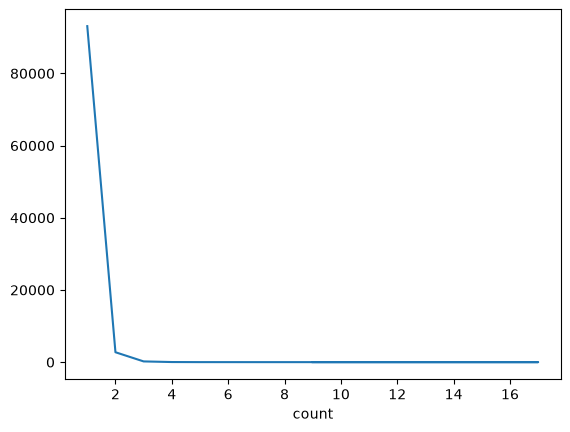

In [40]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot();

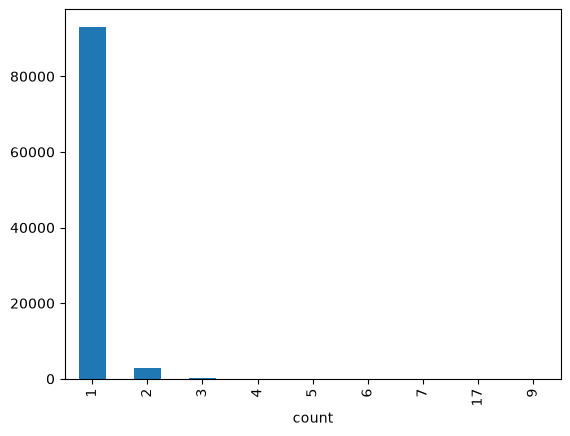

In [41]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot(kind='bar');

In [58]:
(customers_df['customer_unique_id'].value_counts()>=3).sum()

np.int64(252)

In [60]:
100*(customers_df['customer_unique_id'].value_counts()>=3).mean()

np.float64(0.26223776223776224)

**Percentage of ordering 3 or more is 0.26224 %**


In [61]:
(customers_df['customer_unique_id'].value_counts()>1).sum()

np.int64(2997)

In [62]:
100*(customers_df['customer_unique_id'].value_counts()>1).mean()

np.float64(3.1187562437562435)

**Percentage of repeat customers is 3.11876 %**

In [44]:
customer_orders_payments_df['customer_unique_id'].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
6359f309b166b0196dbf7ad2ac62bb5a     1
da62f9e57a76d978d02ab5362c509660     1
737520a9aad80b3fbbdad19b66b37b30     1
5097a5312c8b157bb7be58ae360ef43c     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 96095, dtype: int64

In [45]:
customer_orders_payments_df[filtering_recency]['customer_unique_id'].value_counts().value_counts()

count
1    8975
2      93
3       7
4       2
Name: count, dtype: int64

# Customer Lifetime Value

In [69]:
customer_orders_payments_df.groupby('customer_unique_id').total_payment_value.agg(['sum','count','mean']).sort_values(by='mean',ascending=False)

,sum,count,mean
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,13664.08,1,13664.08
763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,6929.31
459bef486812aa25204be022145caa62,6922.21,1,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1,6726.66
...,...,...,...
b33336f46234b24a613ad9064d13106d,10.89,1,10.89
bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,1,10.07
317cfc692e3f86c45c95697c61c853a6,9.59,1,9.59


**2 customers have orders with 0 total cost, is it input error in the data, special offers or exploiting glitch?**

# days between orders

In [52]:
average_days_df = customer_orders_payments_df.sort_values(["customer_unique_id", "order_purchase_timestamp"])

average_days_df["previous_order_date"] = (
    average_days_df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .shift(1)
)

In [53]:
average_days_df["days_between_orders"] = (average_days_df["order_purchase_timestamp"] - average_days_df["order_purchase_timestamp"]).dt.days

In [54]:
(average_days_df['days_between_orders']>0).value_counts()

days_between_orders
False    99440
Name: count, dtype: int64